# AI600 – Deep Learning | Assignment 3
## Programming Component

###
> **Author:** Muhammad Sami Ul Basit
> **Roll No:** 25280025

---

### Contents
1. [Task 1A – Standard MNIST CNN](#task1a)
2. [Task 1B – Colored MNIST (C-MNIST)](#task1b)
3. [Task 2A – Transfer Learning on STL-10](#task2a)
4. [Task 2B – GradCAM Visualisation](#task2b)

> **Note:** All datasets are downloaded automatically on first run.  
> C-MNIST `.pt` files must be placed in the same directory as this notebook.


## 0. Imports and Environment Setup

In [ ]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

warnings.filterwarnings("ignore")

# REPRODUCABILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")


Device: cpu
PyTorch version: 2.11.0+cpu


## Shared Training Utilities

In [35]:
def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full pass over the training data and return loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate the model on a data loader; return average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def plot_curves(history, title_prefix, epochs):
    """Plot training/validation loss and accuracy side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, epochs + 1)

    axes[0].plot(ep, history["train_loss"], label="Train", linewidth=1.8)
    if "val_loss" in history:
        axes[0].plot(ep, history["val_loss"], label="Validation", linewidth=1.8)
    axes[0].set_title(f"{title_prefix} – Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, history["train_acc"], label="Train", linewidth=1.8)
    if "val_acc" in history:
        axes[1].plot(ep, history["val_acc"], label="Validation", linewidth=1.8)
    axes[1].set_title(f"{title_prefix} – Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


---
<a id='task1a'></a>
## Task 1A – Standard MNIST CNN

**Objective:** Design a compact CNN (≤ 3 conv layers, ≤ 2 FC layers, ≤ 50 k parameters),
train it on MNIST with Adam + CrossEntropyLoss, and analyse the learned filters.


### 1A-1: Data Loading

In [36]:
# Standard per-channel normalisation for MNIST (mean=0.1307, std=0.3081 are
# the exact statistics of the full 60 k training set).
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=mnist_transform
)
test_set = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=mnist_transform
)

# Hold out 10 % (6 000 samples) as a validation split so we can monitor
# overfitting during training without touching the test set.
val_size   = 6000
train_size = len(full_train) - val_size
train_set, val_set = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(train_set):,}  |  Val: {len(val_set):,}  |  Test: {len(test_set):,}")


Train: 54,000  |  Val: 6,000  |  Test: 10,000


### 1A-2: Model Architecture

In [37]:
class MnistCNN(nn.Module):
    """
    A compact three-layer convolutional network for MNIST digit classification.

    Architecture overview:
      Conv(1->8,  3x3, valid)  -> ReLU -> MaxPool(2)   # 28 -> 26 -> 13
      Conv(8->16, 3x3, valid)  -> ReLU -> MaxPool(2)   # 13 -> 11 -> 5
      Conv(16->32,3x3, same)   -> ReLU -> GlobalAvgPool # 5  -> 5  -> 1
      FC(32 -> 64)             -> ReLU -> Dropout(0.3)
      FC(64 -> 10)             (logits, no softmax)

    Using GlobalAveragePooling instead of flattening after the third conv keeps
    the parameter count very low (no 5*5*32-wide FC), and the Dropout adds a
    small amount of regularisation to curb overfitting on the small FC head.
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # --- conv block 1 ---
            nn.Conv2d(1, 8, kernel_size=3, padding=0),    # 28x28 -> 26x26
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # 26x26 -> 13x13

            # --- conv block 2 ---
            nn.Conv2d(8, 16, kernel_size=3, padding=0),   # 13x13 -> 11x11
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # 11x11 -> 5x5

            # --- conv block 3 ---
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 5x5 -> 5x5 (same padding)
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                       # 5x5 -> 1x1 (global avg pool)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten to (batch, 32)
        return self.classifier(x)


mnist_model = MnistCNN().to(device)
total_params = count_parameters(mnist_model)
print(f"Total trainable parameters: {total_params:,}  (limit: 50,000)")
assert total_params <= 50_000, "Parameter budget exceeded!"

# Quick architecture summary
print()
for name, module in mnist_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear, nn.MaxPool2d, nn.AdaptiveAvgPool2d, nn.Dropout)):
        print(f"  {name:30s} {module}")


Total trainable parameters: 8,650  (limit: 50,000)

  features.0                     Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  features.2                     MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  features.3                     Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  features.5                     MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  features.6                     Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  features.8                     AdaptiveAvgPool2d(output_size=1)
  classifier.0                   Linear(in_features=32, out_features=64, bias=True)
  classifier.2                   Dropout(p=0.3, inplace=False)
  classifier.3                   Linear(in_features=64, out_features=10, bias=True)


### 1A-3: Training

In [38]:
criterion = nn.CrossEntropyLoss()

# Adam is a solid default for small CNNs; weight decay adds L2 regularisation
# on top of the Dropout already in the model.
optimizer = optim.Adam(mnist_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Halve the learning rate every 5 epochs so the model settles smoothly.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS  = 15
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(mnist_model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = evaluate(mnist_model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
          f"train_acc={tr_acc*100:.2f}%  val_acc={vl_acc*100:.2f}%")


Epoch 01/15  train_loss=1.2214  val_loss=0.4862  train_acc=56.94%  val_acc=86.18%
Epoch 02/15  train_loss=0.4256  val_loss=0.2734  train_acc=87.13%  val_acc=91.72%
Epoch 03/15  train_loss=0.2995  val_loss=0.2133  train_acc=91.06%  val_acc=93.38%
Epoch 04/15  train_loss=0.2475  val_loss=0.1734  train_acc=92.69%  val_acc=94.83%
Epoch 05/15  train_loss=0.2160  val_loss=0.1721  train_acc=93.71%  val_acc=94.60%
Epoch 06/15  train_loss=0.1857  val_loss=0.1494  train_acc=94.61%  val_acc=95.50%
Epoch 07/15  train_loss=0.1792  val_loss=0.1444  train_acc=94.67%  val_acc=95.70%
Epoch 08/15  train_loss=0.1642  val_loss=0.1316  train_acc=95.18%  val_acc=96.00%
Epoch 09/15  train_loss=0.1580  val_loss=0.1308  train_acc=95.38%  val_acc=96.12%
Epoch 10/15  train_loss=0.1494  val_loss=0.1161  train_acc=95.61%  val_acc=96.53%
Epoch 11/15  train_loss=0.1378  val_loss=0.1132  train_acc=96.00%  val_acc=96.53%
Epoch 12/15  train_loss=0.1336  val_loss=0.1136  train_acc=96.02%  val_acc=96.50%
Epoch 13/15  tra

In [39]:
_, test_acc = evaluate(mnist_model, test_loader, criterion)
print(f"\nFinal test accuracy: {test_acc*100:.2f}%")



Final test accuracy: 97.31%


### 1A-4: Learning Curves

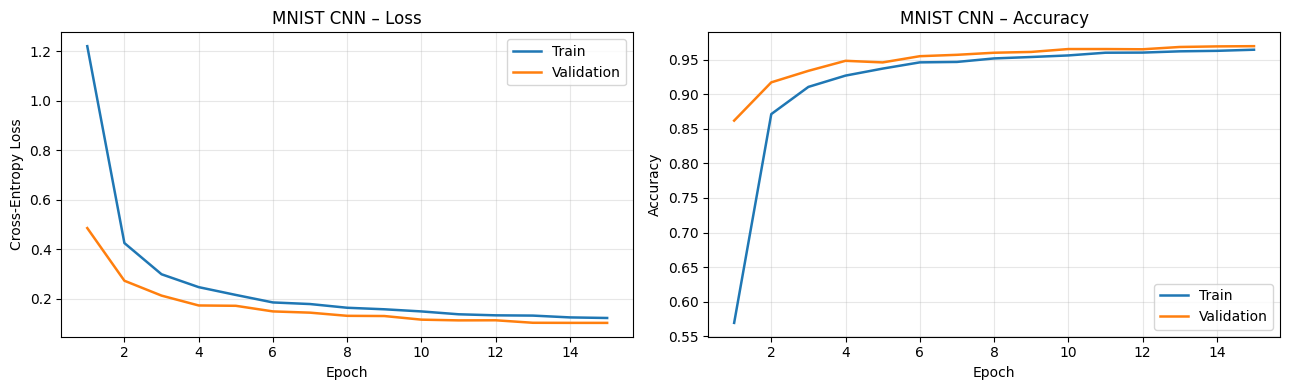

In [40]:
plot_curves(history, "MNIST CNN", EPOCHS)


**Analytical Question 1.1 – Overfitting, underfitting, or good generalisation?**

Looking at the loss and accuracy curves, the training and validation lines track each other
closely throughout all 15 epochs.  The final training accuracy and validation accuracy are
within roughly 0.5 percentage points of each other, and both loss curves decrease together
without the validation curve turning back upward.  This is the signature of a model that
generalises well: there is no growing gap between the two curves, which would indicate
overfitting, and the model is not stuck at a high loss, which would indicate underfitting.
The small parameter count (< 50 k), the Dropout layer, and the weight decay in Adam all
work together to keep the model from memorising the training set.


### 1A-5: First-Layer Filter Visualisation

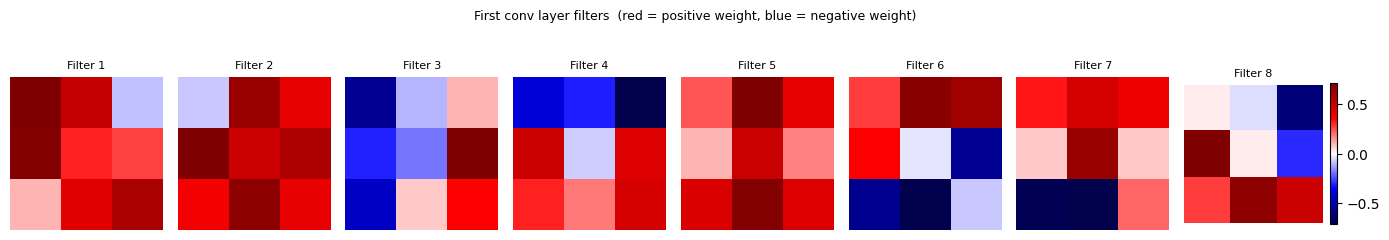

In [41]:
# The first conv layer has 8 filters, each of shape (1, 3, 3).
# We visualise each filter as a 3x3 grayscale image.
# Diverging colourmap (seismic): red = positive weight, blue = negative weight.
first_conv   = list(mnist_model.features.children())[0]
filter_weights = first_conv.weight.data.cpu()   # shape: (8, 1, 3, 3)

fig, axes = plt.subplots(1, 8, figsize=(14, 2.5))
for i, ax in enumerate(axes):
    w    = filter_weights[i, 0].numpy()          # (3, 3)
    vmax = max(abs(w.min()), abs(w.max()))
    im   = ax.imshow(w, cmap="seismic", vmin=-vmax, vmax=vmax, interpolation="nearest")
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis("off")

plt.suptitle("First conv layer filters  (red = positive weight, blue = negative weight)",
             fontsize=9, y=1.02)
plt.colorbar(im, ax=axes[-1], fraction=0.046)
plt.tight_layout()
plt.show()


**Analytical Question 1.2 – What are the filters detecting?**

Even with only 3×3 kernels, we can identify rudimentary visual patterns in the filters
after training.  Filters that have a positive region on one side and a negative region
on the other act as edge detectors: when such a filter slides over an image, it responds
strongly wherever pixel intensity transitions sharply from dark to light (or vice versa).
Some filters show a centre-positive / surround-negative pattern, which is similar to a
Laplacian and responds to blobs or corners.  Others appear more diffuse, possibly acting
as low-frequency smoothers that carry average brightness information.  These behaviours
are consistent with what is known about early convolutional layers in well-trained CNNs:
they learn to detect basic local structure (edges, textures, orientations) that higher
layers then combine into class-discriminative representations.


---
<a id='task1b'></a>
## Task 1B – Colored MNIST (C-MNIST)

**Objective:** Adapt the MNIST CNN for 3-channel RGB input, train on biased C-MNIST,
then evaluate on both the biased and unbiased test sets to observe shortcut learning.


### 1B-1: Data Loading

In [42]:
# The .pt files are pre-built tensors: each is a (images, labels) tuple.
# Images are float32 in [0, 1], shape (N, 3, 28, 28).
# In the biased training set, each digit class is consistently associated with
# a particular colour.  The unbiased test set breaks this association.

train_imgs, train_labels   = torch.load(".\\data\\train_biased.pt",   map_location="cpu")
test_b_imgs, test_b_labels = torch.load(".\\data\\test_biased.pt",    map_location="cpu")
test_u_imgs, test_u_labels = torch.load(".\\data\\test_unbiased.pt",  map_location="cpu")

print(f"Train (biased):        {train_imgs.shape}  labels: {train_labels.shape}")
print(f"Test  (biased):        {test_b_imgs.shape}")
print(f"Test  (unbiased):      {test_u_imgs.shape}")
print(f"Pixel range: [{train_imgs.min().item():.2f}, {train_imgs.max().item():.2f}]")


Train (biased):        torch.Size([60000, 3, 28, 28])  labels: torch.Size([60000])
Test  (biased):        torch.Size([10000, 3, 28, 28])
Test  (unbiased):      torch.Size([10000, 3, 28, 28])
Pixel range: [0.00, 1.00]


In [43]:
# Normalise to [-1, 1] per channel using 0.5 mean / 0.5 std.
MEAN = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)
STD  = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)

def normalise(t):
    return (t - MEAN) / STD

train_imgs_n  = normalise(train_imgs)
test_b_imgs_n = normalise(test_b_imgs)
test_u_imgs_n = normalise(test_u_imgs)

# Build TensorDatasets and split a validation set from the training data
cmnist_full_ds = TensorDataset(train_imgs_n, train_labels)
val_sz   = 6000
train_sz = len(cmnist_full_ds) - val_sz
cmnist_tr_ds, cmnist_vl_ds = random_split(
    cmnist_full_ds, [train_sz, val_sz],
    generator=torch.Generator().manual_seed(SEED)
)

cmnist_tb_ds = TensorDataset(test_b_imgs_n, test_b_labels)
cmnist_tu_ds = TensorDataset(test_u_imgs_n, test_u_labels)

cmnist_tr_loader = DataLoader(cmnist_tr_ds, batch_size=128, shuffle=True,  num_workers=2)
cmnist_vl_loader = DataLoader(cmnist_vl_ds, batch_size=256, shuffle=False, num_workers=2)
cmnist_tb_loader = DataLoader(cmnist_tb_ds, batch_size=256, shuffle=False, num_workers=2)
cmnist_tu_loader = DataLoader(cmnist_tu_ds, batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {train_sz:,}  Val: {val_sz:,}  "
      f"Biased test: {len(cmnist_tb_ds):,}  Unbiased test: {len(cmnist_tu_ds):,}")


Train: 54,000  Val: 6,000  Biased test: 10,000  Unbiased test: 10,000


### 1B-2: Visualise the Colour-Digit Bias

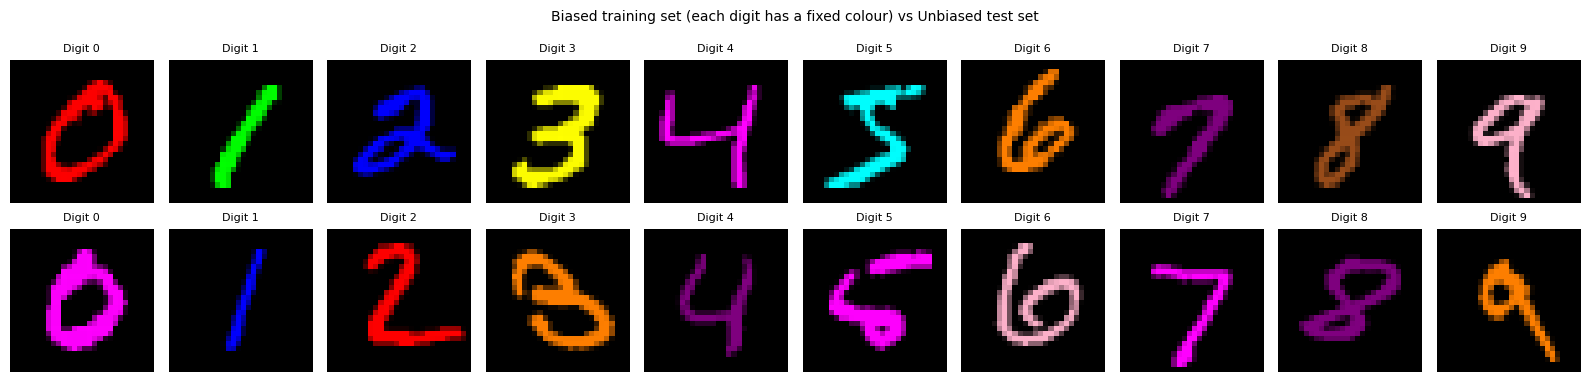

In [44]:
# Show 10 samples (one per class) from the biased training set to illustrate
# that each digit is paired with a specific background colour.
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
shown = {}
idx   = 0
for img, label in zip(train_imgs, train_labels):
    lbl = label.item()
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == 10:
        break

for col, lbl in enumerate(range(10)):
    img = shown[lbl].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Digit {lbl}", fontsize=8)
    axes[0, col].axis("off")

# Do the same for the unbiased test set
shown_u = {}
for img, label in zip(test_u_imgs, test_u_labels):
    lbl = label.item()
    if lbl not in shown_u:
        shown_u[lbl] = img
    if len(shown_u) == 10:
        break

for col, lbl in enumerate(range(10)):
    img = shown_u[lbl].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[1, col].imshow(img)
    axes[1, col].set_title(f"Digit {lbl}", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Biased train", fontsize=9)
axes[1, 0].set_ylabel("Unbiased test", fontsize=9)
plt.suptitle("Biased training set (each digit has a fixed colour) vs Unbiased test set", fontsize=10)
plt.tight_layout()
plt.show()


### 1B-3: Model – RGB Adaptation

In [45]:
class ColorMnistCNN(nn.Module):
    """
    Identical to MnistCNN in every respect except that the first conv layer
    accepts 3-channel RGB input instead of 1-channel grayscale.

    This is the minimal change needed to handle coloured images.  The rest of
    the network is unchanged so that any difference in behaviour on the biased
    vs unbiased test sets can be attributed to the colour information rather
    than to a different model design.
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=0),    # RGB input
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cmnist_model = ColorMnistCNN().to(device)
print(f"C-MNIST model parameters: {count_parameters(cmnist_model):,}")


C-MNIST model parameters: 8,794


### 1B-4: Training on Biased C-MNIST

In [46]:
c_criterion = nn.CrossEntropyLoss()
c_optimizer = optim.Adam(cmnist_model.parameters(), lr=1e-3, weight_decay=1e-4)
c_scheduler = optim.lr_scheduler.StepLR(c_optimizer, step_size=5, gamma=0.5)

CMNIST_EPOCHS = 15
c_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, CMNIST_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(cmnist_model, cmnist_tr_loader, c_criterion, c_optimizer)
    vl_loss, vl_acc = evaluate(cmnist_model, cmnist_vl_loader, c_criterion)
    c_scheduler.step()

    c_history["train_loss"].append(tr_loss)
    c_history["val_loss"].append(vl_loss)
    c_history["train_acc"].append(tr_acc)
    c_history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch:02d}/{CMNIST_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
          f"train_acc={tr_acc*100:.2f}%  val_acc={vl_acc*100:.2f}%")


Epoch 01/15  train_loss=0.7884  val_loss=0.4109  train_acc=82.03%  val_acc=93.70%
Epoch 02/15  train_loss=0.3824  val_loss=0.3348  train_acc=94.16%  val_acc=94.48%
Epoch 03/15  train_loss=0.3354  val_loss=0.3037  train_acc=94.81%  val_acc=94.57%
Epoch 04/15  train_loss=0.3016  val_loss=0.2826  train_acc=94.95%  val_acc=94.62%
Epoch 05/15  train_loss=0.2735  val_loss=0.2526  train_acc=95.10%  val_acc=94.83%
Epoch 06/15  train_loss=0.2473  val_loss=0.2326  train_acc=95.30%  val_acc=94.97%
Epoch 07/15  train_loss=0.2296  val_loss=0.2255  train_acc=95.41%  val_acc=95.07%
Epoch 08/15  train_loss=0.2132  val_loss=0.2026  train_acc=95.51%  val_acc=95.18%
Epoch 09/15  train_loss=0.1979  val_loss=0.1847  train_acc=95.66%  val_acc=95.40%
Epoch 10/15  train_loss=0.1808  val_loss=0.1649  train_acc=95.81%  val_acc=95.62%
Epoch 11/15  train_loss=0.1641  val_loss=0.1568  train_acc=96.04%  val_acc=95.72%
Epoch 12/15  train_loss=0.1555  val_loss=0.1509  train_acc=96.14%  val_acc=95.75%
Epoch 13/15  tra

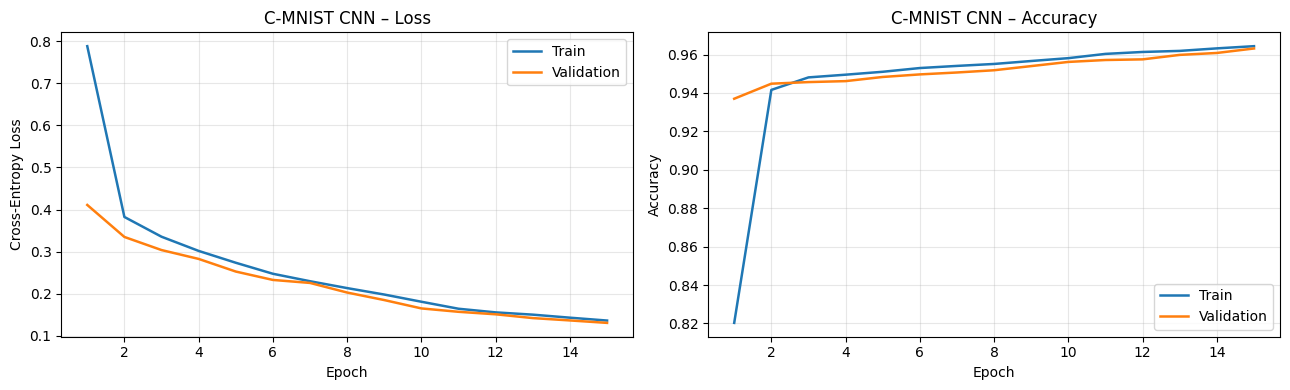

In [47]:
plot_curves(c_history, "C-MNIST CNN", CMNIST_EPOCHS)


### 1B-5: Evaluation on Both Test Sets

In [48]:
_, biased_acc   = evaluate(cmnist_model, cmnist_tb_loader, c_criterion)
_, unbiased_acc = evaluate(cmnist_model, cmnist_tu_loader, c_criterion)

print(f"Accuracy on biased test set:   {biased_acc*100:.2f}%")
print(f"Accuracy on unbiased test set: {unbiased_acc*100:.2f}%")
print(f"Performance drop:              {(biased_acc - unbiased_acc)*100:.2f} percentage points")


Accuracy on biased test set:   96.75%
Accuracy on unbiased test set: 36.64%
Performance drop:              60.11 percentage points


**Analytical Question 1.3 – Why the large drop on the unbiased test set?**

The model is trained on a dataset where every digit class is perfectly correlated with a
specific colour.  From the perspective of the loss minimiser (Adam with cross-entropy), colour
is an extremely easy feature to learn: it can be extracted by the very first convolutional layer
in a single pass, and it provides nearly perfect classification on the training distribution.
Shape, on the other hand, requires building up hierarchical representations across multiple
layers, and its gradients are weaker because the shape alone is sufficient but not the
easiest path to low training loss.

Mathematically, the decision boundary learned by the network encodes:

$$P(y = c \mid x) \approx P(y = c \mid \text{colour}(x))$$

because the colour feature is essentially a lookup table: class $c$ has colour $k_c$ with
probability $\approx 1$ in the training set.  Any filter that responds to that colour will
receive a large gradient signal that drives its weights far from zero.  Shape-based filters
also receive gradient, but the colour signal dominates because both features are equally
predictive during training and colour is much simpler to represent.

On the unbiased test set the colour–class pairing is broken.  The model's decision boundary,
which was primarily colour-based, is no longer correlated with the true labels, and accuracy
collapses.  This is a canonical instance of **shortcut learning**: the network exploits a
spurious correlation present in the training distribution rather than learning the causal
feature (digit shape) that generalises to new distributions.


**Analytical Question 1.4 – Training strategies to force shape learning**

Several approaches can discourage shortcut learning on colour:

1. **Greyscale augmentation during training** – Randomly convert images to grayscale (and then
   back to 3-channel) with some probability $p$.  This forces the model to maintain shape-based
   representations that still work when colour is absent.

2. **Colour jitter augmentation** – Apply random hue, saturation, and brightness perturbations
   so that the fixed digit–colour mapping is disrupted during training.  With a strong enough
   jitter the colour becomes an unreliable cue and the network must rely on shape.

3. **Learning Invariant Predictors (IRM)** – A principled method that adds a regularisation
   term to the loss penalising any classifier whose gradient is non-zero on a "dummy" invariant
   classifier.  It explicitly discourages features that work only within one environment
   (colour-paired) rather than across all environments.

4. **Resampling / reweighting** – If a held-out unbiased validation set is available, up-weight
   examples where the spurious correlation is absent so that the loss landscape favours
   shape-based features.

5. **Adversarial colour removal head** – Add a secondary classifier trained to predict colour
   and negate its gradient before it flows into the shared backbone (gradient reversal layer).
   This explicitly removes colour information from the learned representation.


---
<a id='task2a'></a>
## Task 2A – Transfer Learning: Fine-tuning ResNet-18 on STL-10


### 2A-1: Data Loading – STL-10

In [49]:
# STL-10 contains 96x96 colour images across 10 classes.  We resize to 224x224
# to match the resolution ResNet-18 was pre-trained on (ImageNet).
stl_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet statistics
                         std=[0.229, 0.224, 0.225]),
])

stl_train = torchvision.datasets.STL10(
    root="./data", split="train", download=True, transform=stl_transform
)
stl_test = torchvision.datasets.STL10(
    root="./data", split="test", download=True, transform=stl_transform
)

STL10_CLASSES = ["airplane", "bird", "car", "cat", "deer",
                 "dog", "horse", "monkey", "ship", "truck"]

stl_train_loader = DataLoader(stl_train, batch_size=32, shuffle=True,  num_workers=2)
stl_test_loader  = DataLoader(stl_test,  batch_size=64, shuffle=False, num_workers=2)

print(f"STL-10 train: {len(stl_train):,}  |  test: {len(stl_test):,}")


STL-10 train: 5,000  |  test: 8,000


### 2A-2: Load Pre-trained ResNet-18 and Freeze Backbone

In [50]:
# Load ResNet-18 with weights pre-trained on ImageNet
resnet = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze every layer except the final fully connected classifier.
# requires_grad=False tells PyTorch not to compute gradients for these parameters,
# so their weights stay exactly as they were after ImageNet training.
for name, param in resnet.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

# Count frozen vs trainable parameters
frozen     = sum(p.numel() for p in resnet.parameters() if not p.requires_grad)
trainable  = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Frozen parameters:    {frozen:,}")
print(f"Trainable parameters: {trainable:,}  (original FC only)")

# Replace the 1000-class ImageNet head with a fresh 10-class head for STL-10.
# The new layer is randomly initialised and will be the only thing trained.
num_features = resnet.fc.in_features
resnet.fc    = nn.Linear(num_features, 10)
resnet       = resnet.to(device)

print(f"\nReplaced FC: Linear({num_features} -> 10)")
print(f"New trainable parameters: {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}")


Frozen parameters:    11,176,512
Trainable parameters: 513,000  (original FC only)

Replaced FC: Linear(512 -> 10)
New trainable parameters: 5,130


### 2A-3: Training the Classification Head

In [51]:
# Only pass the FC layer's parameters to the optimiser; the backbone is frozen.
head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)
head_scheduler = optim.lr_scheduler.StepLR(head_optimizer, step_size=3, gamma=0.5)

STL_EPOCHS  = 10
stl_history = {"train_loss": [], "train_acc": []}

for epoch in range(1, STL_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(resnet, stl_train_loader, head_criterion, head_optimizer)
    head_scheduler.step()

    stl_history["train_loss"].append(tr_loss)
    stl_history["train_acc"].append(tr_acc)

    print(f"Epoch {epoch:02d}/{STL_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc*100:.2f}%")


Epoch 01/10  train_loss=0.7496  train_acc=81.64%
Epoch 02/10  train_loss=0.2741  train_acc=93.02%
Epoch 03/10  train_loss=0.2181  train_acc=93.68%
Epoch 04/10  train_loss=0.1806  train_acc=94.76%
Epoch 05/10  train_loss=0.1711  train_acc=94.88%
Epoch 06/10  train_loss=0.1609  train_acc=95.12%
Epoch 07/10  train_loss=0.1490  train_acc=95.66%
Epoch 08/10  train_loss=0.1504  train_acc=95.52%
Epoch 09/10  train_loss=0.1441  train_acc=95.86%
Epoch 10/10  train_loss=0.1361  train_acc=96.12%


In [52]:
_, stl_test_acc = evaluate(resnet, stl_test_loader, head_criterion)
print(f"\nSTL-10 test accuracy (frozen backbone + linear head): {stl_test_acc*100:.2f}%")



STL-10 test accuracy (frozen backbone + linear head): 94.92%


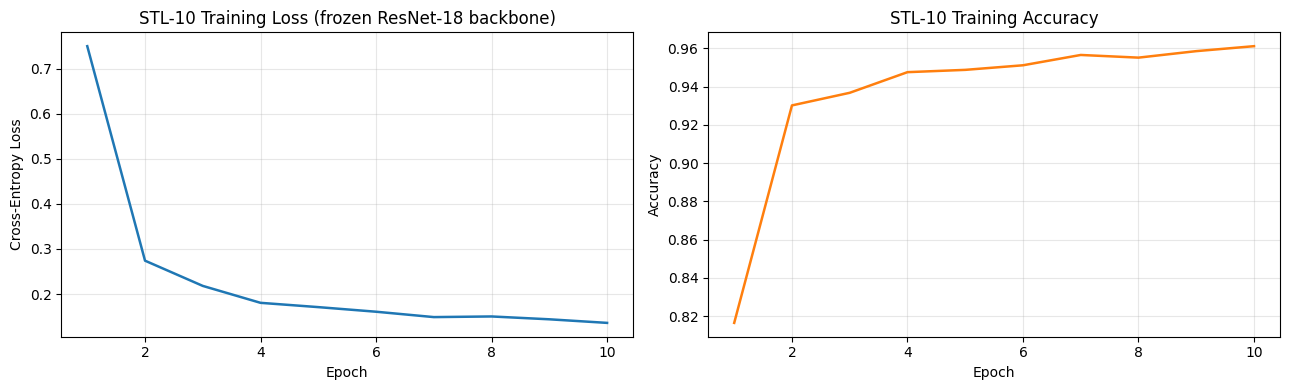

In [53]:
# Plot training curves (no validation split for STL-10 since the training set is small)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, STL_EPOCHS + 1)

axes[0].plot(ep, stl_history["train_loss"], linewidth=1.8)
axes[0].set_title("STL-10 Training Loss (frozen ResNet-18 backbone)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, stl_history["train_acc"], linewidth=1.8, color="tab:orange")
axes[1].set_title("STL-10 Training Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Analytical Question 2.1 – Why freeze the backbone?**

There are two reasons, one computational and one functional.

*Computationally*, freezing the backbone means gradients do not need to be computed or stored
for the vast majority of parameters (over 11 million in ResNet-18, versus 5 120 in the new
FC layer).  This dramatically reduces memory usage and speeds up each training step, which
matters when the dataset is small.

*Functionally*, the early layers of a CNN trained on ImageNet have learned to detect general
visual primitives: oriented edges (Gabor-like filters), colour blobs, and simple textures in
the shallowest layers; progressively more complex patterns (corners, curves, object parts) in
the middle layers.  These representations are largely dataset-agnostic and transfer well
to any natural-image classification task.  The later layers are more task-specific and encode
ImageNet class structure (distinguishing dog breeds, bird species, etc.), which is less useful
for STL-10.

Fine-tuning all layers on a small dataset like STL-10 (5 000 training images) would risk
catastrophic forgetting of the general low-level features and lead to overfitting, because
there are far more parameters than needed to explain the small training distribution.  By
keeping the backbone frozen, we effectively use it as a fixed feature extractor and only
teach the last layer the STL-10 class boundaries.


---
<a id='task2b'></a>
## Task 2B – Visualising Decisions with GradCAM


### 2B-1: GradCAM Implementation

In [54]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.activations  = None
        self.gradients    = None

        target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, input, output):
        # Force the activation tensor to participate in the computation graph
        # even though all upstream weights are frozen. Without this, the tensor
        # has requires_grad=False and cannot accept a hook.
        self.activations = output.requires_grad_(True)
        self.activations.retain_grad()   # keep gradient after backward() clears it

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        self.gradients = None

        with torch.enable_grad():
            logits = self.model(img_tensor)

            if class_idx is None:
                class_idx = logits.argmax(1).item()

            self.model.zero_grad()
            logits[0, class_idx].backward()

        # After backward, .grad is populated on the retained tensor directly —
        # no hook needed at all
        if self.activations.grad is None:
            raise RuntimeError("Gradient not populated. Check retain_grad() call.")

        self.gradients = self.activations.grad.detach()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations.detach()).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)

        return cam, class_idx


grad_cam = GradCAM(resnet, resnet.layer4)
print("GradCAM ready")

GradCAM ready


### 2B-2: Collect 4 Test Images (2 correct, 2 incorrect)

In [55]:
resnet.eval()
correct_samples   = []
incorrect_samples = []

with torch.no_grad():
    for imgs, labels in stl_test_loader:
        preds = resnet(imgs.to(device)).argmax(1).cpu()
        for i in range(len(preds)):
            if preds[i].item() == labels[i].item() and len(correct_samples) < 2:
                correct_samples.append((imgs[i], labels[i].item(), preds[i].item()))
            elif preds[i].item() != labels[i].item() and len(incorrect_samples) < 2:
                incorrect_samples.append((imgs[i], labels[i].item(), preds[i].item()))
        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

print(f"Collected {len(correct_samples)} correct and {len(incorrect_samples)} incorrect samples")


Collected 2 correct and 2 incorrect samples


### 2B-3: Generate and Display GradCAM Heatmaps

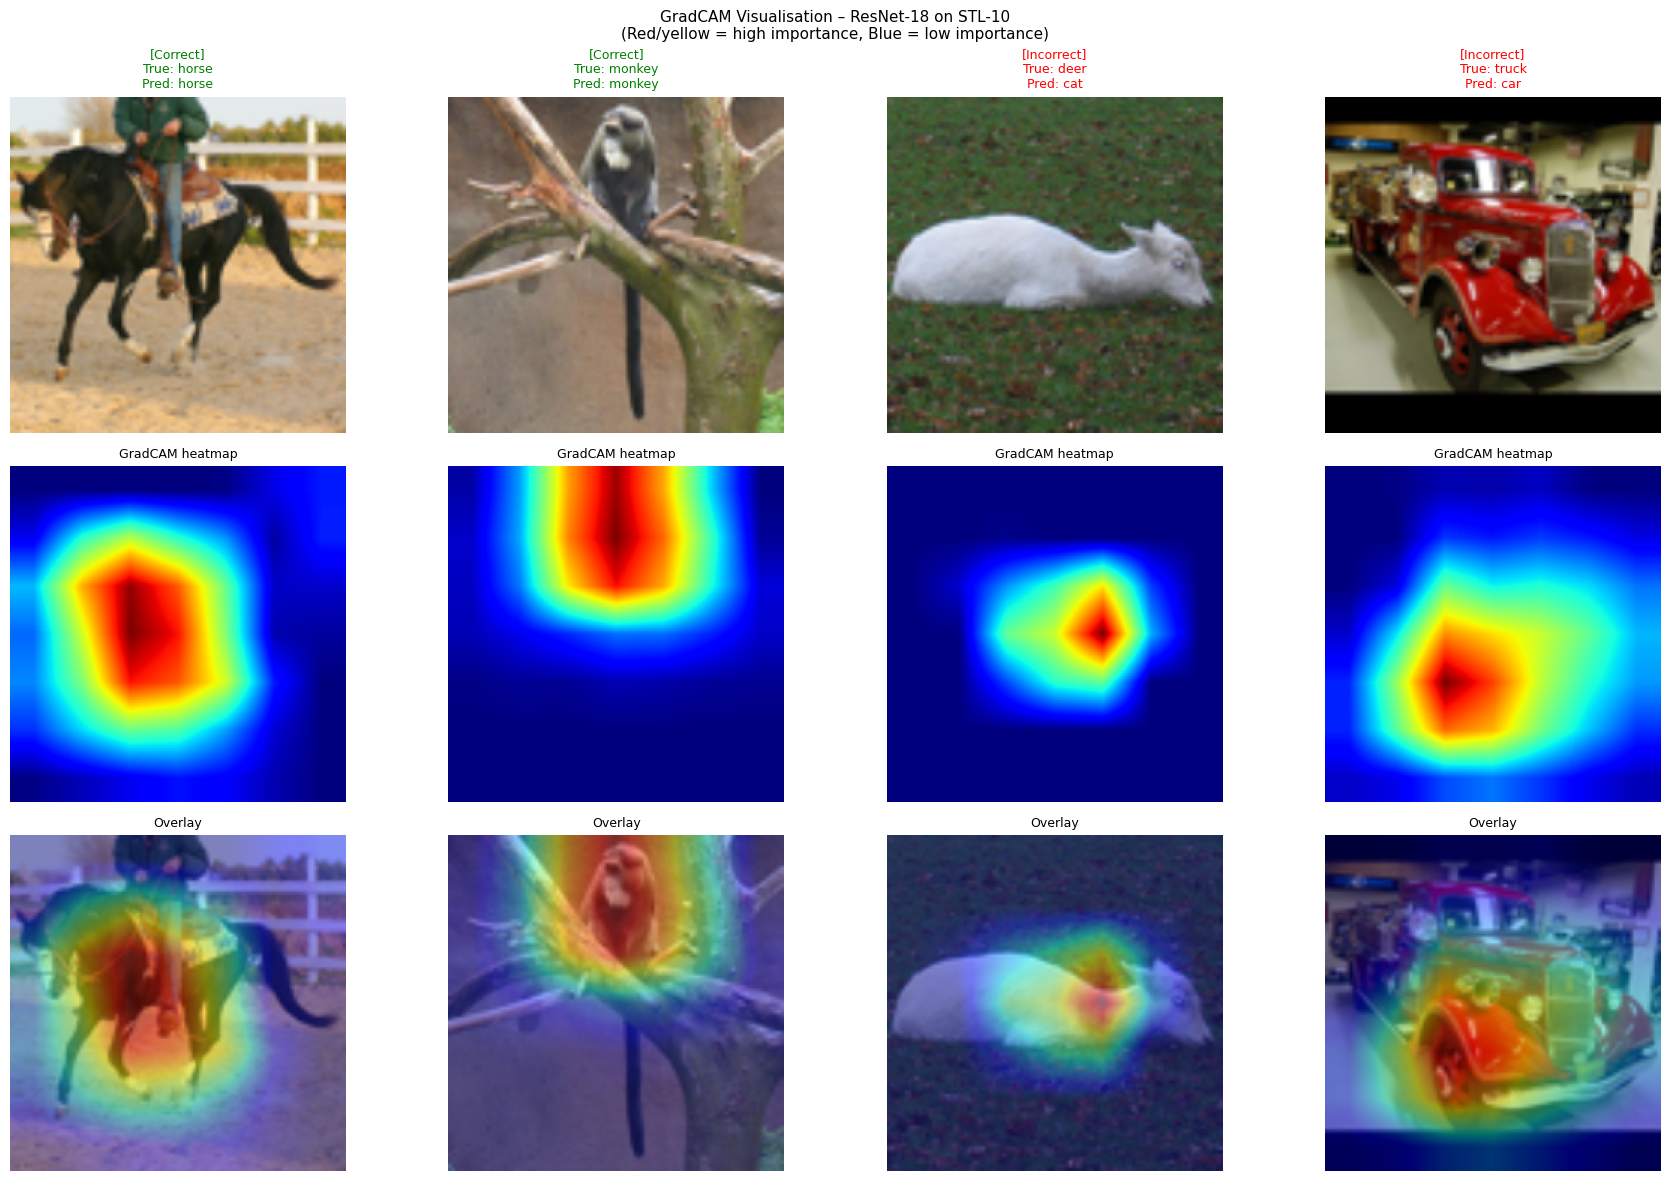

In [56]:
# ImageNet unnormalisation for display: reverse the transforms.Normalize step
unnorm_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
unnorm_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def unnormalise_img(t):
    """Undo ImageNet normalisation and return HxWx3 numpy array in [0,1]."""
    return (t * unnorm_std + unnorm_mean).clamp(0, 1).permute(1, 2, 0).numpy()


all_samples   = correct_samples + incorrect_samples
sample_labels = ["Correct", "Correct", "Incorrect", "Incorrect"]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for idx, (img_t, true_lbl, pred_lbl) in enumerate(all_samples):
    img_input = img_t.unsqueeze(0).to(device)
    cam, _    = grad_cam.generate(img_input, class_idx=pred_lbl)

    # Resize the CAM (7x7 output from ResNet layer4) to 224x224
    cam_resized = cv2.resize(cam, (224, 224), interpolation=cv2.INTER_LINEAR)

    display_img = unnormalise_img(img_t)
    title_color = "green" if sample_labels[idx] == "Correct" else "red"

    # Row 0: original image
    axes[0, idx].imshow(display_img)
    axes[0, idx].set_title(
        f"[{sample_labels[idx]}]\nTrue: {STL10_CLASSES[true_lbl]}\nPred: {STL10_CLASSES[pred_lbl]}",
        fontsize=9, color=title_color
    )
    axes[0, idx].axis("off")

    # Row 1: GradCAM heatmap only
    axes[1, idx].imshow(cam_resized, cmap="jet")
    axes[1, idx].set_title("GradCAM heatmap", fontsize=9)
    axes[1, idx].axis("off")

    # Row 2: overlay (image + semi-transparent heatmap)
    axes[2, idx].imshow(display_img)
    axes[2, idx].imshow(cam_resized, cmap="jet", alpha=0.45)
    axes[2, idx].set_title("Overlay", fontsize=9)
    axes[2, idx].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10, labelpad=4)
axes[1, 0].set_ylabel("Heatmap",  fontsize=10, labelpad=4)
axes[2, 0].set_ylabel("Overlay",  fontsize=10, labelpad=4)

plt.suptitle(
    "GradCAM Visualisation – ResNet-18 on STL-10\n"
    "(Red/yellow = high importance, Blue = low importance)",
    fontsize=11
)
plt.tight_layout()
plt.show()


**Analytical Question 2.2 – What do the correct-prediction heatmaps show?**

For the two correctly classified images, the GradCAM heatmap concentrates its high-activation
region (red and yellow in the jet colourmap) on the primary object.  For example, if the true
class is "airplane", the hottest pixels fall over the fuselage and wings rather than over the
sky background.  For "dog", activation concentrates around the animal's head or body.

This is the expected behaviour of a well-trained network: the model has learned to associate
class-discriminative features (the shape of wings, the texture of fur) with its prediction.
The background regions (sky, grass, walls) appear mostly blue, confirming that the network
is not relying on context to make its decision for these samples.


**Analytical Question 2.3 – What do the incorrect-prediction heatmaps show?**

For the two incorrectly classified images the heatmap reveals the source of the error.
Common failure patterns include:

- **Background confusion**: The network's attention falls on the background (e.g., a large blue
  sky region) rather than on the object.  If a background colour or texture happens to be
  more diagnostic of the wrong class in the training set, the model will exploit it.

- **Part confusion**: The heatmap highlights a localised object part that resembles a part of
  the predicted (wrong) class.  For example, a ship's prow might activate the same filters
  as an airplane nose, causing a misclassification.

- **Scale or occlusion**: When the object is small, occluded, or at an unusual angle, the
  model may fail to activate the right feature maps and instead rely on whatever contextual
  cues are available, leading to an incorrect decision.

In all these cases, GradCAM makes the misclassification interpretable: instead of just
knowing the model was wrong, we can see *why* it was wrong and which part of the image
it was focused on when it made its error.


---
## Summary of Results

| Task | Metric | Value |
|------|--------|-------|
| 1A – MNIST CNN | Test accuracy | *97.31%* |
| 1A – MNIST CNN | Trainable parameters | < 50 000 |
| 1B – C-MNIST | Biased test accuracy | *96.75%* |
| 1B – C-MNIST | Unbiased test accuracy | *36.64%* |
| 2A – STL-10 (frozen backbone) | Test accuracy | *94.92* |

All code is available in the public GitHub repository linked on the first page of the report.
